In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
import statsmodels.api as sm
sns.set_style("whitegrid")
import warnings
warnings.filterwarnings("ignore")

In [4]:
#STAGE 1 - OBTAIN

#Load the UK Civil Aviation Authority (CAA) dataset and understand its basic structure

df = pd.read_csv("2025_Annual_Punctuality_Statistics_Full_Analysis.csv")

#DATASET DETAILS
print(f"\nDataset shape: {df.shape}")
print(f"Total Rows: {len(df)}")
print(f"Total Columns: {len(df.columns)}")


Dataset shape: (7655, 25)
Total Rows: 7655
Total Columns: 25


In [5]:
#DATASET OVERVIEW
#Show first 5 rows
print(f"\nFirst 5 rows:")
df.head()


First 5 rows:


,run_date,reporting_period,reporting_airport,origin_destination_country,origin_destination,airline_name,scheduled_charter,number_flights_matched,actual_flights_unmatched,number_flights_cancelled,...,flights_between_61_and_120_minutes_late_percent,flights_between_121_and_180_minutes_late_percent,flights_between_181_and_360_minutes_late_percent,flights_more_than_360_minutes_late_percent,flights_unmatched_percent,flights_cancelled_percent,average_delay_mins,previous_year_month_flights_matched,previous_year_month_early_to_15_mins_late_percent,previous_year_month_average_delay
0,25/02/2026 19:22,2025,ABERDEEN,ARMENIA,YEREVAN,AVION EXPRESS MALTA LTD,C,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,24.000000,0,0.000000,0.000000
1,25/02/2026 19:22,2025,ABERDEEN,AZERBAIJAN,BAKU (HEYDER ALIYEV INT'L),AIR HAMBURG,C,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1,100.000000,0.000000
2,25/02/2026 19:22,2025,ABERDEEN,BULGARIA,BURGAS,BH AIR,C,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,26,61.538462,17.269231
3,25/02/2026 19:22,2025,ABERDEEN,CZECH REPUBLIC,PRAGUE,EASYJET UK LTD,S,2,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,28.500000,0,0.000000,0.000000
4,25/02/2026 19:22,2025,ABERDEEN,CZECH REPUBLIC,PRAGUE,JET2.COM LTD,C,3,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,9.333333,0,0.000000,0.000000


In [6]:
#Show data types
print("\nAll Column names & Data types:")
print(df.dtypes)


All Column names & Data types:
run_date                                               object
reporting_period                                        int64
reporting_airport                                      object
origin_destination_country                             object
origin_destination                                     object
airline_name                                           object
scheduled_charter                                      object
number_flights_matched                                  int64
actual_flights_unmatched                                int64
number_flights_cancelled                                int64
flights_more_than_15_minutes_early_percent            float64
flights_15_minutes_early_to_1_minute_early_percent    float64
flights_0_to_15_minutes_late_percent                  float64
flights_between_16_and_30_minutes_late_percent        float64
flights_between_31_and_60_minutes_late_percent        float64
flights_between_61_and_120_minutes_lat

In [7]:
#Show basic statistics
print("\nBasic statistics:")
print(df.describe())


Basic statistics:
       reporting_period  number_flights_matched  actual_flights_unmatched  \
count            7655.0             7655.000000               7655.000000   
mean             2025.0              249.580144                  0.032920   
std                 0.0              622.629859                  0.433402   
min              2025.0                0.000000                  0.000000   
25%              2025.0                0.000000                  0.000000   
50%              2025.0                6.000000                  0.000000   
75%              2025.0              208.000000                  0.000000   
max              2025.0             8392.000000                 25.000000   

       number_flights_cancelled  flights_more_than_15_minutes_early_percent  \
count               7655.000000                                 7655.000000   
mean                   2.623514                                    4.843543   
std                   11.303120                   

In [8]:
#1. Checking Missing Values
print("\nChecking for missing values")
missing = df.isnull().sum()
print(f"Missing values: {missing.sum()}")


Checking for missing values
Missing values: 0


In [9]:
#2. Checking for duplicate rows
print("\nChecking for duplicate rows")
duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")

if duplicates>0:
  df=df.drop_duplicates()
  print(f"Duplicates removed. Rows remaining: {len(df)}")
else:
  print("No Duplicates found")


Checking for duplicate rows
Duplicate rows found: 0
No Duplicates found


In [10]:
#3. Checking data types
print("\nChecking data types")
print(f"Numeric columns: {df.select_dtypes(include="number").shape[1]}")
print(f"Text columns: {df.select_dtypes(include="object").shape[1]}")
print(f"Text column names: {list(df.select_dtypes(include="object").columns)}")


Checking data types
Numeric columns: 19
Text columns: 6
Text column names: ['run_date', 'reporting_airport', 'origin_destination_country', 'origin_destination', 'airline_name', 'scheduled_charter']


In [11]:
#4. Filtering Rows where flights actually operated
print("\nFiltering rows with zero flights")
rows_before = len(df)
df = df[df["number_flights_matched"]>0].copy()
rows_after = len(df)
print(f"Rows before filtering: {rows_before}")
print(f"Rows after filtering: {rows_after}")
print(f"Rows removed: {rows_before - rows_after}")
print(f"Reason: Rows with zero flights contain no delay information")


Filtering rows with zero flights
Rows before filtering: 7655
Rows after filtering: 5695
Rows removed: 1960
Reason: Rows with zero flights contain no delay information


In [12]:
#5. Encoding scheduled/charter
#S = Scheduled, C = Charter
print("\nEncoding scheduled charter column")
print(f"Original Values: {df["scheduled_charter"].unique()}")
df["is_scheduled"]= df["scheduled_charter"].map({"S": 1, "C": 0})
print(f"Encoded as: S=1 (Scheduled), C=0 (Charter)")


Encoding scheduled charter column
Original Values: ['C' 'S']
Encoded as: S=1 (Scheduled), C=0 (Charter)


In [13]:
#6. Creating Target Variable
#As per IATA standard, a flight is delayed if it departs/arrives 15+ minutes late
#Using average_delay_mins >= 15 as the threshold for 'Delayed'

from sklearn.preprocessing import normalize

print("\nCreating target variable (delay_class)")
print("Condition: delay_class = 1 if average_delay_mins >= 15, else 0")
df["delay_class"] = np.where(df["average_delay_mins"] >= 15,1,0)

print("\nClass distribution: ")
print(df["delay_class"].value_counts())

print(f"\nPercentage:")
print(df["delay_class"].value_counts(normalize=True)*100)


Creating target variable (delay_class)
Condition: delay_class = 1 if average_delay_mins >= 15, else 0

Class distribution: 
delay_class
1    3074
0    2621
Name: count, dtype: int64

Percentage:
delay_class
1    53.977173
0    46.022827
Name: proportion, dtype: float64


In [14]:
print("\nAfter Scrub step, the working dataset consists of:")
print(f"Rows: {len(df)}, Columns: {len(df.columns)}")


After Scrub step, the working dataset consists of:
Rows: 5695, Columns: 27


In [15]:
print(f"Overall mean delay: {df["average_delay_mins"].mean():.1f} mins")
print(f"Overall median delay: {df["average_delay_mins"].median():.1f} mins")
print(f"Previous year mean: {df["previous_year_month_average_delay"].mean():.1f} mins")
print(f"Previous year median: {df["previous_year_month_average_delay"].median():.1f} mins")

Overall mean delay: 24.5 mins
Overall median delay: 15.9 mins
Previous year mean: 15.3 mins
Previous year median: 13.0 mins


In [16]:
#Define features and target
print("\nDefining features and target variable")

feature_cols = [
    "number_flights_matched",
    "flights_cancelled_percent",
    "flights_unmatched_percent",
    "flights_between_16_and_30_minutes_late_percent",
    "flights_between_31_and_60_minutes_late_percent",
    "flights_between_61_and_120_minutes_late_percent",
    "flights_more_than_15_minutes_early_percent",
    "flights_0_to_15_minutes_late_percent",
    "previous_year_month_average_delay",
    "is_scheduled"]

X = df[feature_cols]
y = df["delay_class"]

print(f"Features selected: {len(feature_cols)}")
print(f"Target variable: delay_class (0=On-Time, 1=Delayed)")



Defining features and target variable
Features selected: 10
Target variable: delay_class (0=On-Time, 1=Delayed)


In [17]:
#Train / Test Split
print("\nSplitting data (80% train, 20% test)")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training rows: {len(X_train)}")
print(f"Test rows: {len(X_test)}")


Splitting data (80% train, 20% test)
Training rows: 4556
Test rows: 1139


In [18]:
#UNIVARIATE MODEL
#Single Feature Baseline
#Feature used: previous_year_month_average_delay

#Select feature
X_train_uni = X_train[["previous_year_month_average_delay"]]
X_test_uni = X_test[["previous_year_month_average_delay"]]

#Train  model
clf_uni = LogisticRegression(max_iter=1000)
clf_uni.fit(X_train_uni, y_train)

#Make predictions
y_pred_uni = clf_uni.predict(X_test_uni)
y_proba_uni = clf_uni.predict_proba(X_test_uni)[:, 1]
auc_uni = roc_auc_score(y_test, y_proba_uni)

#Calculate metrics
cm_uni = confusion_matrix(y_test, y_pred_uni)
tn_u, fp_u, fn_u, tp_u = cm_uni.ravel()

accuracy_uni = (tp_u + tn_u) / (tp_u + tn_u + fp_u + fn_u)
precision_uni = tp_u / (tp_u + fp_u)
recall_uni = tp_u / (tp_u + fn_u)
f1_uni = 2 * precision_uni * recall_uni / (precision_uni + recall_uni)


print(f"\nUnivariate Model Results:")
print(f"Accuracy: {accuracy_uni * 100:.1f}%")
print(f"Precision: {precision_uni * 100:.1f}%")
print(f"Recall: {recall_uni * 100:.1f}%")
print(f"F1-Score: {f1_uni:.3f}")
print(f"AUC-ROC : {auc_uni:.3f}")




Univariate Model Results:
Accuracy: 56.2%
Precision: 59.6%
Recall: 62.4%
F1-Score: 0.610
AUC-ROC : 0.624


In [19]:
#MULTIVARIATE MODEL

#Features used: all 10 operational features

#Train model
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

#Make predictions
y_pred_test  = clf.predict(X_test)
y_proba_test = clf.predict_proba(X_test)[:, 1]

#Calculate metrics
cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()

accuracy  = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * precision * recall / (precision + recall)
auc = roc_auc_score(y_test, y_proba_test)

print(f"\nMultivariate Model Results:")
print(f"Accuracy: {accuracy * 100:.1f}%")
print(f"Precision: {precision * 100:.1f}%")
print(f"Recall: {recall * 100:.1f}%")
print(f"F1-Score: {f1:.3f}")
print(f"AUC-ROC: {auc:.3f}")



Multivariate Model Results:
Accuracy: 86.4%
Precision: 90.7%
Recall: 83.8%
F1-Score: 0.871
AUC-ROC: 0.937


In [20]:
#Model Comparison
print("MODEL COMPARISON SUMMARY")

print(f"Univariate (1 feature): {accuracy_uni * 100:.1f}% accuracy")
print(f"Multivariate (10 features): {accuracy * 100:.1f}% accuracy")
print(f"\nAdding 9 more features improved accuracy by {(accuracy - accuracy_uni) * 100:.1f}%")


MODEL COMPARISON SUMMARY
Univariate (1 feature): 56.2% accuracy
Multivariate (10 features): 86.4% accuracy

Adding 9 more features improved accuracy by 30.2%


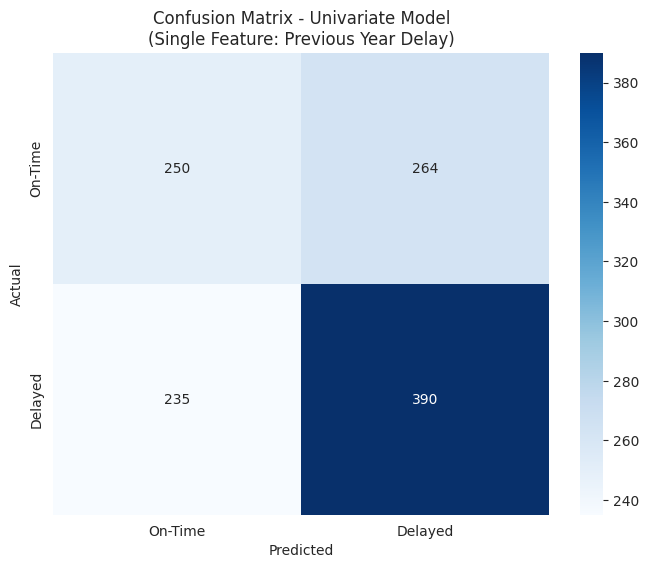

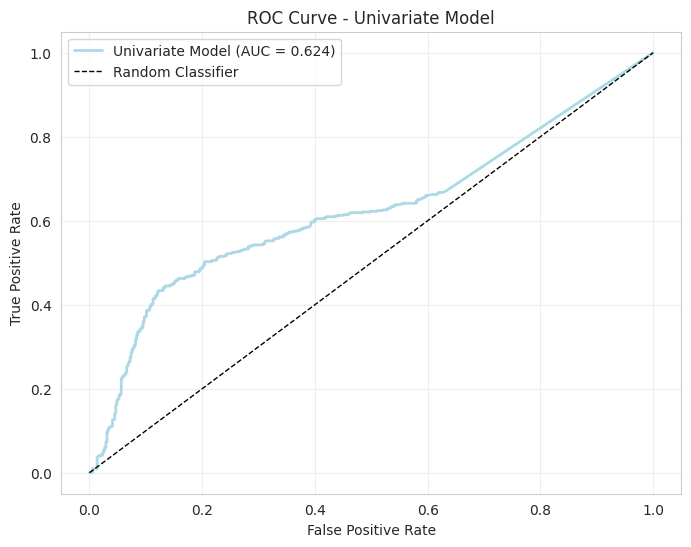

In [21]:
#Univariate Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_uni, annot=True, fmt="d", cmap="Blues",xticklabels=["On-Time", "Delayed"],yticklabels=["On-Time", "Delayed"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Univariate Model\n(Single Feature: Previous Year Delay)")
plt.show()

#Univariate ROC Curve
y_proba_uni = clf_uni.predict_proba(X_test_uni)[:, 1]
auc_uni = roc_auc_score(y_test, y_proba_uni)
fpr_uni, tpr_uni, thresholds_uni = roc_curve(y_test, y_proba_uni)

plt.figure(figsize=(8, 6))
plt.plot(fpr_uni, tpr_uni,label=f"Univariate Model (AUC = {auc_uni:.3f})",linewidth=2, color="lightblue")
plt.plot([0, 1], [0, 1], "k--", linewidth=1,label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Univariate Model")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [22]:
#Calculate AUC for univariate
y_proba_uni = clf_uni.predict_proba(X_test_uni)[:, 1]
auc_uni = roc_auc_score(y_test, y_proba_uni)

print("UNIVARIATE MODEL PERFORMANCE SUMMARY")
print(f"\nAccuracy: {accuracy_uni*100:.1f}%")
print(f"Precision: {precision_uni*100:.1f}%")
print(f"Recall: {recall_uni*100:.1f}%")
print(f"F1-Score: {f1_uni:.3f}")
print(f"AUC-ROC: {auc_uni:.3f}")

print(f"\nTest routes: {len(y_test)}")
print(f"Correct: {tp_u + tn_u}")
print(f"Misclassified: {fp_u + fn_u}")
print(f"False Positives: {fp_u}(predicted delayed, actually on-time)")
print(f"False Negatives: {fn_u}(predicted on-time, actually delayed)")


UNIVARIATE MODEL PERFORMANCE SUMMARY

Accuracy: 56.2%
Precision: 59.6%
Recall: 62.4%
F1-Score: 0.610
AUC-ROC: 0.624

Test routes: 1139
Correct: 640
Misclassified: 499
False Positives: 264(predicted delayed, actually on-time)
False Negatives: 235(predicted on-time, actually delayed)


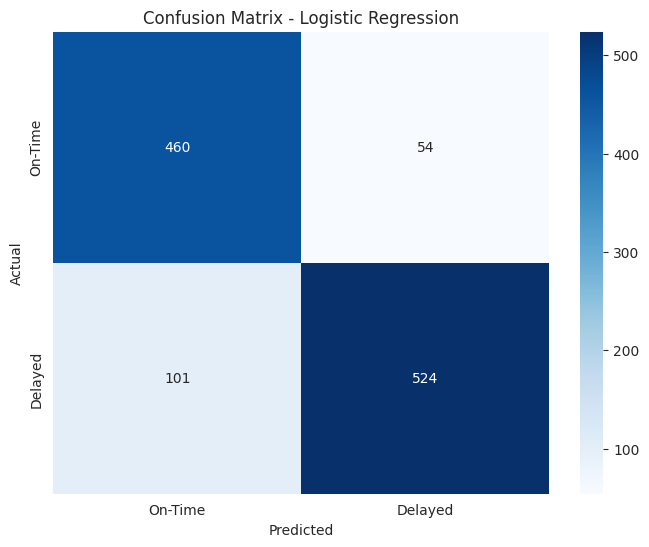

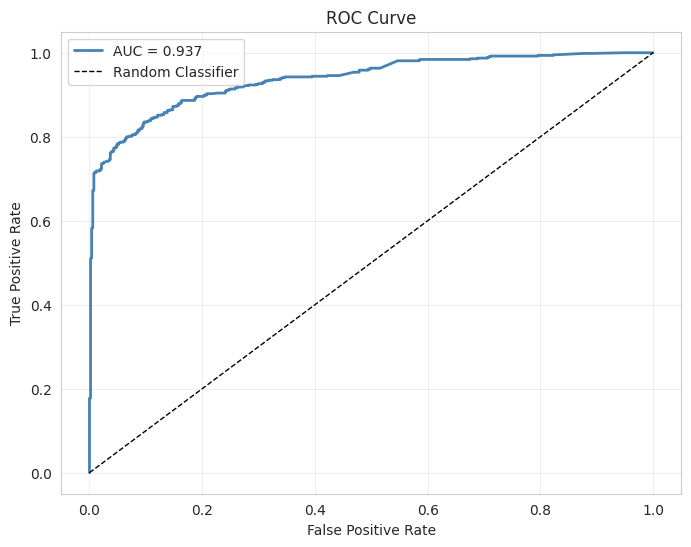

In [23]:
#Multivariate Confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm,annot=True,fmt="d", cmap="Blues", xticklabels=["On-Time", "Delayed"],yticklabels=["On-Time", "Delayed"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

#Multivariate ROC curve
fpr,tpr, thresholds = roc_curve(y_test, y_proba_test)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label = f"AUC = {auc:.3f}", linewidth=2, color="steelblue")
plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [24]:
print("MULTIVARIATE MODEL PERFORMANCE SUMMARY")
print(f"\nAccuracy: {accuracy*100:.1f}%")
print(f"Precision: {precision*100:.1f}%")
print(f"Recall: {recall*100:.1f}%")
print(f"F1-Score: {f1:.3f}")
print(f"AUC-ROC: {auc:.3f}")
print(f"\nTest routes: {len(y_test)}")
print(f"Correct: {tp + tn}")
print(f"Misclassified: {fp + fn}")
print(f"False Positives: {fp}(predicted delayed, actually on-time)")
print(f"False Negatives: {fn}(predicted on-time, actually delayed)")

MULTIVARIATE MODEL PERFORMANCE SUMMARY

Accuracy: 86.4%
Precision: 90.7%
Recall: 83.8%
F1-Score: 0.871
AUC-ROC: 0.937

Test routes: 1139
Correct: 984
Misclassified: 155
False Positives: 54(predicted delayed, actually on-time)
False Negatives: 101(predicted on-time, actually delayed)
